In [1]:
# Cell 1 (REPLACE) — Safe GPU setup (before any TensorFlow-heavy work)
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

from pathlib import Path
import json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras import mixed_precision

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, accuracy_score

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"

ART_DIR = PROJECT_ROOT / "artifacts" / "stage2b"
MODEL_DIR = PROJECT_ROOT / "models" / "stage2b_cnn"
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
assert len(gpus) > 0, "No GPU detected."

for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

# disable mixed precision for this stage stability
mixed_precision.set_global_policy("float32")
print("Mixed precision policy:", mixed_precision.global_policy())


2026-04-07 03:03:12.403887: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-07 03:03:12.678009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-07 03:03:12.825331: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-07 03:03:12.826023: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-07 03:03:13.041714: I tensorflow/core/platform/cpu_feature_gua

TensorFlow: 2.16.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision policy: <DTypePolicy "float32">


In [2]:
# Cell 2 (fixed) — load data, resolve real image dirs, build image-level table
from pathlib import Path
import json
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/teamspace/studios/this_studio/accessops_coco_ai")
CSV_PATH = PROJECT_ROOT / "artifacts" / "captions_clean_with_splits.csv"

df = pd.read_csv(CSV_PATH)
df["comment_clean"] = df["comment_clean"].astype(str).str.strip().str.lower()
df["split"] = df["split"].astype(str).str.strip().str.lower()
df["image_name"] = df["image_name"].astype(str).str.strip()
df = df[df["comment_clean"].str.len() > 0].reset_index(drop=True)

# include your current folder layout (artifacts/data/coco/...)
train_candidates = [
    PROJECT_ROOT / "data" / "coco" / "train2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "train2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "train2017",
]
val_candidates = [
    PROJECT_ROOT / "data" / "coco" / "val2017",
    PROJECT_ROOT / "artifacts" / "data" / "coco" / "val2017",
    PROJECT_ROOT / "data" / "coco" / "raw" / "val2017",
]

TRAIN_IMG_DIR = next((p for p in train_candidates if p.exists()), train_candidates[0])
VAL_IMG_DIR = next((p for p in val_candidates if p.exists()), val_candidates[0])

print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR, TRAIN_IMG_DIR.exists())
print("VAL_IMG_DIR:", VAL_IMG_DIR, VAL_IMG_DIR.exists())

def build_path(row):
    base = TRAIN_IMG_DIR if row["split"] == "train" else VAL_IMG_DIR  # val + test from val2017
    return str(base / row["image_name"])

df["image_path"] = df.apply(build_path, axis=1)

exists_mask = df["image_path"].map(lambda p: Path(p).exists())
df = df[exists_mask].reset_index(drop=True)

# FIXED: use agg with named output (no rename(columns=...) on Series)
img_df = (
    df.groupby(["split", "image_name", "image_path"], as_index=False)
      .agg(all_captions=("comment_clean", lambda s: " ".join(s.tolist())))
)

train_df = img_df[img_df["split"] == "train"].reset_index(drop=True)
val_df   = img_df[img_df["split"] == "val"].reset_index(drop=True)
test_df  = img_df[img_df["split"] == "test"].reset_index(drop=True)

split_sizes = {
    "train_images": int(len(train_df)),
    "val_images": int(len(val_df)),
    "test_images": int(len(test_df)),
}
(ART_DIR / "selected_split_sizes.json").write_text(json.dumps(split_sizes, indent=2), encoding="utf-8")

print(json.dumps(split_sizes, indent=2))
assert len(train_df) > 100000, "Train split too small."
assert len(val_df) > 2000 and len(test_df) > 2000, "Val/test split too small."


TRAIN_IMG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/train2017 True
VAL_IMG_DIR: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/data/coco/val2017 True
{
  "train_images": 118287,
  "val_images": 2500,
  "test_images": 2500
}


In [3]:
# Cell 3 — Keyword vocabulary (reuse Stage 2A vocab for fair comparison)
vocab_path_stage2a = PROJECT_ROOT / "artifacts" / "stage2" / "keyword_vocab.json"

if vocab_path_stage2a.exists():
    keyword_vocab = json.loads(vocab_path_stage2a.read_text(encoding="utf-8"))
    print("Loaded Stage 2A keyword vocab:", len(keyword_vocab))
else:
    TOP_K = 600
    MIN_WORD_FREQ = 30
    STOPWORDS = set(ENGLISH_STOP_WORDS)

    counter = Counter()
    for text in tqdm(train_df["all_captions"], total=len(train_df), desc="Counting tokens"):
        for t in text.split():
            if len(t) < 3 or (not t.isalpha()) or (t in STOPWORDS):
                continue
            counter[t] += 1

    candidates = [w for w, c in counter.items() if c >= MIN_WORD_FREQ]
    keyword_vocab = sorted(candidates, key=lambda w: counter[w], reverse=True)[:TOP_K]
    print("Built keyword vocab:", len(keyword_vocab))

(ART_DIR / "keyword_vocab.json").write_text(json.dumps(keyword_vocab, indent=2), encoding="utf-8")
vocab2id = {w: i for i, w in enumerate(keyword_vocab)}
id2vocab = {i: w for w, i in vocab2id.items()}
K = len(keyword_vocab)
print("K:", K)
assert K > 0, "Keyword vocab is empty."


Loaded Stage 2A keyword vocab: 600
K: 600


In [4]:
# Cell 4 — Build multi-label targets
def text_to_label_vector(text, vocab2id, K):
    vec = np.zeros((K,), dtype=np.float32)
    toks = set(text.split())
    idxs = [vocab2id[t] for t in toks if t in vocab2id]
    if idxs:
        vec[idxs] = 1.0
    return vec

def build_xy(df_split, split_name):
    paths = df_split["image_path"].astype(str).to_numpy()
    names = df_split["image_name"].astype(str).to_numpy()
    Y = np.zeros((len(df_split), K), dtype=np.float32)
    for i, text in enumerate(tqdm(df_split["all_captions"], total=len(df_split), desc=f"Labels {split_name}")):
        Y[i] = text_to_label_vector(text, vocab2id, K)
    return names, paths, Y

train_names, train_paths, y_train = build_xy(train_df, "train")
val_names, val_paths, y_val = build_xy(val_df, "val")
test_names, test_paths, y_test = build_xy(test_df, "test")

print("y_train:", y_train.shape, "avg labels/image:", float(y_train.sum(axis=1).mean()))
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)


Labels train:   0%|          | 0/118287 [00:00<?, ?it/s]

Labels val:   0%|          | 0/2500 [00:00<?, ?it/s]

Labels test:   0%|          | 0/2500 [00:00<?, ?it/s]

y_train: (118287, 600) avg labels/image: 11.983176231384277
y_val: (2500, 600)
y_test: (2500, 600)


In [5]:
# Cell 5 (low-memory pipeline, full dataset unchanged)
IMG_SIZE = 160
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

def load_example(path, y):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32) / 255.0
    return img, y

def augment(img, y):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.04)
    img = tf.image.random_contrast(img, lower=0.95, upper=1.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, y

def make_ds(paths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, y))
    ds = ds.map(lambda p, t: load_example(p, tf.cast(t, tf.float32)), num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(min(len(paths), 10000), seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(1)
    return ds

train_ds = make_ds(train_paths, y_train, training=True)
val_ds = make_ds(val_paths, y_val, training=False)
test_ds = make_ds(test_paths, y_test, training=False)

print("Datasets ready.")


2026-04-07 03:04:13.101421: I tensorflow/core/common_runtime/gpu/gpu_process_state.cc:238] Using CUDA malloc Async allocator for GPU: 0
2026-04-07 03:04:13.103259: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79187 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:00:05.0, compute capability: 8.0


Datasets ready.


In [6]:
# Cell 6 (lighter CNN, no BatchNorm to avoid moments OOM)
tf.keras.backend.clear_session()

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = layers.Conv2D(16, 3, padding="same", activation="relu")(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.GlobalAveragePooling2D()(x)

x = layers.Dropout(0.30)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.25)(x)
outputs = layers.Dense(K, activation="sigmoid")(x)

model = models.Model(inputs, outputs)
model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    jit_compile=False
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 600)            │       154,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,664 (1.09 MB)

 Trainable params: 284,664 (1.09 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Cell 7 (train)
ckpt = MODEL_DIR / "cnn_keyword_baseline_final.keras"
cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    callbacks.ModelCheckpoint(filepath=str(ckpt), monitor="val_loss", save_best_only=True),
    callbacks.TerminateOnNaN(),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=cb,
    verbose=1
)


Epoch 1/20


2026-04-07 03:04:29.745815: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


14786/14786 ━━━━━━━━━━━━━━━━━━━━ 287s 18ms/step - loss: 0.0840 - val_loss: 0.0781 - learning_rate: 0.0010
Epoch 2/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 129s 8ms/step - loss: 0.0763 - val_loss: 0.0738 - learning_rate: 0.0010
Epoch 3/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 126s 8ms/step - loss: 0.0741 - val_loss: 0.0727 - learning_rate: 0.0010
Epoch 4/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 126s 8ms/step - loss: 0.0730 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 5/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 127s 8ms/step - loss: 0.0722 - val_loss: 0.0706 - learning_rate: 0.0010
Epoch 6/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 126s 8ms/step - loss: 0.0716 - val_loss: 0.0699 - learning_rate: 0.0010
Epoch 7/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 126s 8ms/step - loss: 0.0712 - val_loss: 0.0698 - learning_rate: 0.0010
Epoch 8/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 127s 8ms/step - loss: 0.0709 - val_loss: 0.0697 - learning_rate: 0.0010
Epoch 9/20
14786/14786 ━━━━━━━━━━━━━━━━━━━━ 123s 8ms/step - loss: 0.0706 - val_los

In [8]:
# Cell 8 — Threshold tuning + metrics
import json
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, hamming_loss, accuracy_score

# Predict
val_prob = model.predict(val_ds, verbose=1)
test_prob = model.predict(test_ds, verbose=1)

def compute_metrics(y_true, y_prob, th):
    y_pred = (y_prob >= th).astype(np.int32)
    yt = y_true.astype(np.int32)
    return {
        "threshold": float(th),
        "micro_precision": float(precision_score(yt, y_pred, average="micro", zero_division=0)),
        "micro_recall": float(recall_score(yt, y_pred, average="micro", zero_division=0)),
        "micro_f1": float(f1_score(yt, y_pred, average="micro", zero_division=0)),
        "hamming_loss": float(hamming_loss(yt, y_pred)),
        "subset_accuracy": float(accuracy_score(yt, y_pred)),
    }

thresholds = np.round(np.arange(0.10, 0.51, 0.05), 2)
val_rows = [compute_metrics(y_val, val_prob, th) for th in thresholds]
th_df = pd.DataFrame(val_rows).sort_values("micro_f1", ascending=False).reset_index(drop=True)

best_th = float(th_df.loc[0, "threshold"])
test_m = compute_metrics(y_test, test_prob, best_th)

metrics = {
    "best_threshold_from_val": best_th,
    "val_best_micro_f1": float(th_df.loc[0, "micro_f1"]),
    "test_micro_precision": test_m["micro_precision"],
    "test_micro_recall": test_m["micro_recall"],
    "test_micro_f1": test_m["micro_f1"],
    "test_hamming_loss": test_m["hamming_loss"],
    "test_subset_accuracy": test_m["subset_accuracy"],
    "keyword_vocab_size": int(y_test.shape[1]),
    "train_images": int(len(train_df)),
    "val_images": int(len(val_df)),
    "test_images": int(len(test_df)),
}

th_df.to_csv(ART_DIR / "threshold_search_val.csv", index=False)
(ART_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")

print(json.dumps(metrics, indent=2))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
{
  "best_threshold_from_val": 0.15,
  "val_best_micro_f1": 0.34830152531132563,
  "test_micro_precision": 0.3182347646529359,
  "test_micro_recall": 0.40218809595503363,
  "test_micro_f1": 0.3553197463901985,
  "test_hamming_loss": 0.029080666666666668,
  "test_subset_accuracy": 0.0,
  "keyword_vocab_size": 600,
  "train_images": 118287,
  "val_images": 2500,
  "test_images": 2500
}


In [9]:
# Metrics table view (val threshold table + final test row)
import pandas as pd
from IPython.display import display

val_table = th_df.copy()
val_table = val_table.sort_values("micro_f1", ascending=False).reset_index(drop=True)

test_table = pd.DataFrame([{
    "threshold": metrics["best_threshold_from_val"],
    "micro_precision": metrics["test_micro_precision"],
    "micro_recall": metrics["test_micro_recall"],
    "micro_f1": metrics["test_micro_f1"],
    "hamming_loss": metrics["test_hamming_loss"],
    "subset_accuracy": metrics["test_subset_accuracy"],
}])

val_table.to_csv(ART_DIR / "metrics_table_val_thresholds.csv", index=False)
test_table.to_csv(ART_DIR / "metrics_table_test_at_best_threshold.csv", index=False)

print("Validation threshold ranking:")
display(val_table)

print("Final test metrics at best threshold:")
display(test_table)


Validation threshold ranking:


,threshold,micro_precision,micro_recall,micro_f1,hamming_loss,subset_accuracy
0,0.15,0.312165,0.393900,0.348302,0.029481,0.0
1,0.20,0.379812,0.313433,0.343445,0.023967,0.0
2,0.25,0.441757,0.255733,0.323939,0.021349,0.0
3,0.10,0.231653,0.510000,0.318594,0.043631,0.0
4,0.30,0.500040,0.210367,0.296145,0.019999,0.0
5,0.35,0.559029,0.173467,0.264774,0.019267,0.0
6,0.40,0.610236,0.139500,0.227088,0.018992,0.0
7,0.45,0.660340,0.111333,0.190541,0.018919,0.0
8,0.50,0.700759,0.089300,0.158413,0.018977,0.0


Final test metrics at best threshold:


,threshold,micro_precision,micro_recall,micro_f1,hamming_loss,subset_accuracy
0,0.15,0.318235,0.402188,0.35532,0.029081,0.0


In [10]:
# Stage 2A vs Stage 2B comparison table
import json
import pandas as pd
from IPython.display import display

m2a_path = PROJECT_ROOT / "artifacts" / "stage2" / "metrics.json"
m2b_path = PROJECT_ROOT / "artifacts" / "stage2b" / "metrics.json"

assert m2a_path.exists(), f"Missing: {m2a_path}"
assert m2b_path.exists(), f"Missing: {m2b_path}"

m2a = json.loads(m2a_path.read_text(encoding="utf-8"))
m2b = json.loads(m2b_path.read_text(encoding="utf-8"))

compare = pd.DataFrame([
    {
        "stage": "Stage 2A (MLP)",
        "best_threshold": m2a.get("best_threshold_from_val"),
        "val_best_micro_f1": m2a.get("val_best_micro_f1"),
        "test_micro_precision": m2a.get("test_micro_precision"),
        "test_micro_recall": m2a.get("test_micro_recall"),
        "test_micro_f1": m2a.get("test_micro_f1"),
        "test_hamming_loss": m2a.get("test_hamming_loss"),
        "test_subset_accuracy": m2a.get("test_subset_accuracy"),
        "train_images": m2a.get("train_images"),
        "val_images": m2a.get("val_images"),
        "test_images": m2a.get("test_images"),
    },
    {
        "stage": "Stage 2B (CNN)",
        "best_threshold": m2b.get("best_threshold_from_val"),
        "val_best_micro_f1": m2b.get("val_best_micro_f1"),
        "test_micro_precision": m2b.get("test_micro_precision"),
        "test_micro_recall": m2b.get("test_micro_recall"),
        "test_micro_f1": m2b.get("test_micro_f1"),
        "test_hamming_loss": m2b.get("test_hamming_loss"),
        "test_subset_accuracy": m2b.get("test_subset_accuracy"),
        "train_images": m2b.get("train_images"),
        "val_images": m2b.get("val_images"),
        "test_images": m2b.get("test_images"),
    }
])

compare["delta_vs_2A_test_micro_f1"] = compare["test_micro_f1"] - float(m2a.get("test_micro_f1", 0.0))
compare["delta_vs_2A_test_hamming_loss"] = compare["test_hamming_loss"] - float(m2a.get("test_hamming_loss", 0.0))

compare.to_csv(PROJECT_ROOT / "artifacts" / "stage2b" / "stage2a_vs_stage2b_comparison.csv", index=False)

display(compare)
print("Saved:", PROJECT_ROOT / "artifacts" / "stage2b" / "stage2a_vs_stage2b_comparison.csv")


,stage,best_threshold,val_best_micro_f1,test_micro_precision,test_micro_recall,test_micro_f1,test_hamming_loss,test_subset_accuracy,train_images,val_images,test_images,delta_vs_2A_test_micro_f1,delta_vs_2A_test_hamming_loss
0,Stage 2A (MLP),0.25,0.453033,0.459057,0.457091,0.458072,0.021551,0.0,118287,2500,2500,0.000000,0.00000
1,Stage 2B (CNN),0.15,0.348302,0.318235,0.402188,0.355320,0.029081,0.0,118287,2500,2500,-0.102752,0.00753


Saved: /teamspace/studios/this_studio/accessops_coco_ai/artifacts/stage2b/stage2a_vs_stage2b_comparison.csv


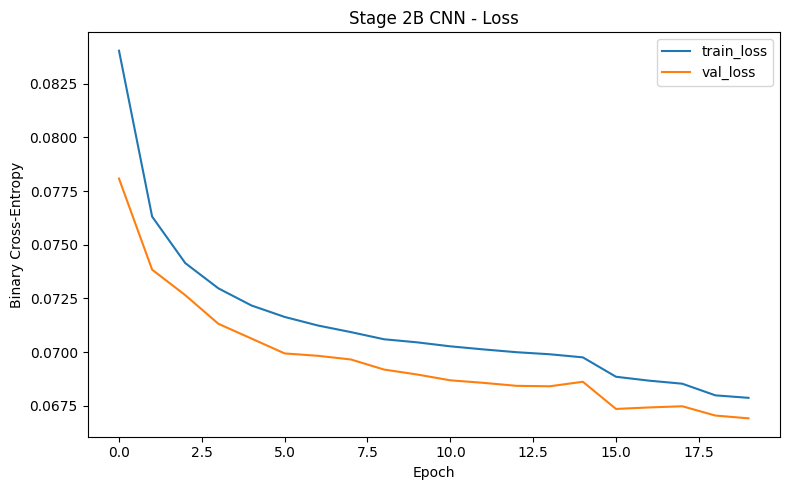

Saved artifacts + model.


In [11]:
# Cell 9 — Save history/plot/samples/model
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# History
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(ART_DIR / "training_history.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(hist_df["loss"], label="train_loss")
plt.plot(hist_df["val_loss"], label="val_loss")
plt.title("Stage 2B CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.legend()
plt.tight_layout()
plt.savefig(ART_DIR / "training_curve_loss.png", dpi=170)
plt.show()

# Vocab map
if "id2vocab" not in globals():
    keyword_vocab = json.loads((ART_DIR / "keyword_vocab.json").read_text(encoding="utf-8"))
    id2vocab = {i: w for i, w in enumerate(keyword_vocab)}

m = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))
best_th = float(m["best_threshold_from_val"])
y_pred_test = (test_prob >= best_th).astype(np.int32)

def decode_keywords(vec_bin, max_k=12):
    idxs = np.where(vec_bin > 0)[0][:max_k]
    return ", ".join([id2vocab[i] for i in idxs])

def decode_top_probs(prob_vec, max_k=12):
    idxs = np.argsort(prob_vec)[::-1][:max_k]
    return ", ".join([id2vocab[i] for i in idxs])

rows = []
sample_n = min(25, len(test_names))
for i in range(sample_n):
    rows.append({
        "image_name": str(test_names[i]),
        "true_keywords": decode_keywords(y_test[i]),
        "pred_keywords_thresholded": decode_keywords(y_pred_test[i]),
        "pred_top12_by_prob": decode_top_probs(test_prob[i]),
    })

pd.DataFrame(rows).to_csv(ART_DIR / "test_keyword_predictions_sample.csv", index=False)

# Save final model
model.save(MODEL_DIR / "cnn_keyword_baseline_final.keras")
print("Saved artifacts + model.")


In [12]:
# Cell 10 — Gate check
import json
import numpy as np

required = [
    ART_DIR / "selected_split_sizes.json",
    ART_DIR / "keyword_vocab.json",
    ART_DIR / "training_history.csv",
    ART_DIR / "training_curve_loss.png",
    ART_DIR / "threshold_search_val.csv",
    ART_DIR / "metrics.json",
    ART_DIR / "test_keyword_predictions_sample.csv",
    MODEL_DIR / "cnn_keyword_baseline_final.keras",
]
for p in required:
    assert p.exists(), f"Missing: {p}"

m = json.loads((ART_DIR / "metrics.json").read_text(encoding="utf-8"))
assert not np.isnan(m["test_micro_f1"]), "test_micro_f1 is NaN"

print("STAGE 2B PASS")
print("Test micro F1:", round(m["test_micro_f1"], 4))


STAGE 2B PASS
Test micro F1: 0.3553
